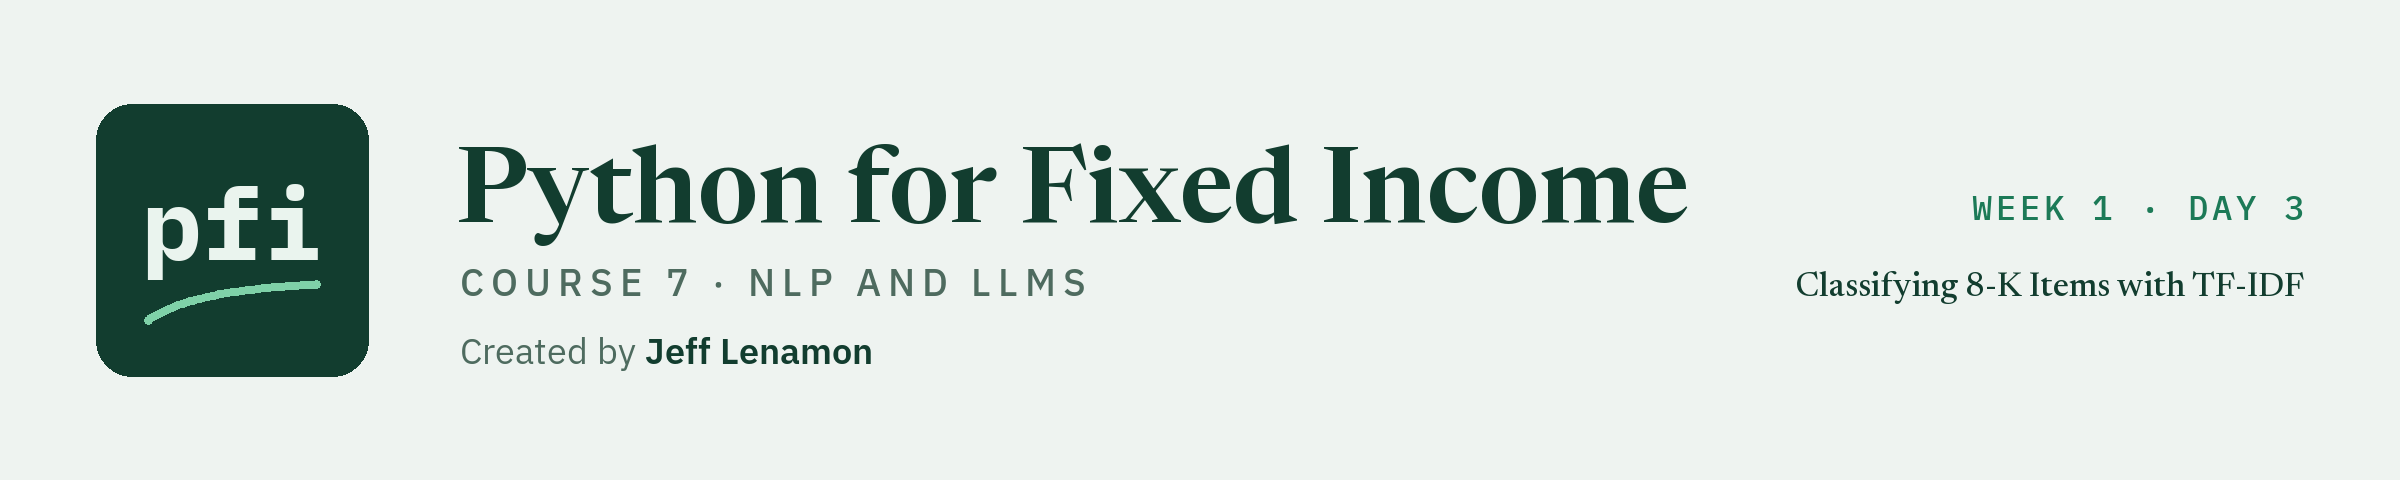

# Classifying 8-K Items with TF-IDF

Week 1, Day 3. Today you train a classifier that assigns each 8-K section its item, split by filing date, find the leak a section's own heading creates, and report recall on the rare items on their own.

**Data:** `course7_8k_items.csv`, 5,126 item sections of Form 8-K current reports filed on EDGAR, 2019 to 2025, each labelled by the item its filer chose: **real**, public records (sec.gov), a sample drawn by the course (DATA.md).

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course7_nlp_and_llms/week1/day3/03_classifying_8k_items_with_tf_idf.ipynb)

A **Form 8-K** is the current report a company files with the SEC between its quarterly and annual reports, to make an event public. The form numbers its events as **items**, and the filer puts each event under its item's heading: Item 1.01 for entering into a material definitive agreement, Item 2.04 for triggering events that accelerate or increase a financial obligation, Item 1.03 for bankruptcy or receivership, and so on. A credit desk reads these every day.

Day 2 turned text into TF-IDF vectors. Today a logistic regression sits on top of them, in one `Pipeline`, and learns to assign each section of an 8-K the item its filer chose. The file holds 5,126 sections under eight items, filed from 2019 to 2025. The day is about doing it honestly: a split by date, a leak found and fixed, and the rare items reported on their own.

**The rules for real documents, as on every day of this course.**

* **The documents are real.** Each section is the text of a Form 8-K that its company filed on EDGAR, a public record, quoted exactly as filed (cut at 300 words by the course's tool), with a source line under every excerpt.
* **The labels are the filers' own.** A section's item is the heading its filer chose. A model's output is "the item the model assigns" or "the model's probability for Item 2.04 in this file", and the true label is "the filer's item". It is never a default signal, never a distress flag or a warning, and never a credit event or a view on the company.
* **Issuer names appear only as the authors of the documents being read**, in the source line. No table in this notebook lists companies, and the Item 5.02 sections, which name officers and directors, are counted by item only: no name from them is printed.

**Rows.** Every model on the 8-K sections in this notebook is fitted on the 3,650 sections filed from 2019 to 2023 and scored on the 741 sections filed in 2024, labelled validation; the 735 sections filed in 2025 are closed until day 10. The AI check in Exercise 4 fits one more model on a random split of the same 2019 to 2024 sections, on purpose, to show what that split does; no 2025 section is used anywhere in this notebook.

Today you will:

1. Read the item codes as text, list the eight items with the SEC's titles, and count the sections by item and year.
2. Split the sections by filing date with `date_split`, and close the 2025 rows.
3. Put each section's heading back and watch a model score near 1.0 by reading the label.
4. Fit `text_classifier` on the bodies, and read its per-item report, the majority-item baseline, and the confusion matrix.
5. Report recall on the rare items, and choose class weights on the validation rows.
6. Read the coefficients `top_terms` returns, and find the item numbers the bodies still hold.
7. Name the model's output, and write the first rows of the experiment log.

Q. Set up today's work folder: the thread settings, the quiet-loading settings, the seed, and today's data file.

In [1]:
# today's setup: thread settings, quiet model loading, the modules, the seed, the course data, a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These lines must run before numpy, pandas, scikit-learn, or PyTorch is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

# the model libraries print download bars and notices; these lines must run before they are imported
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

import importlib
import importlib.metadata
import importlib.util
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("torch", "torch"), ("transformers", "transformers"), ("sentence_transformers", "sentence-transformers"), ("openai", "openai"), ("pydantic", "pydantic"), ("bs4", "beautifulsoup4"), ("pypdf", "pypdf"), ("pypdfium2", "pypdfium2"), ("dotenv", "python-dotenv"), ("pytest", "pytest")]:
    if importlib.util.find_spec(module_name) is None:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.")

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course7_nlp_and_llms/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "torch": "2.14.1", "transformers": "5.19.0", "sentence-transformers": "6.1.0", "openai": "3.26.0", "pydantic": "2.13.5", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name].split("+")[0] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "course7_fomc_statements.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course7_03_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["course7_8k_items.csv"]
for name in DATA_FILES:
    (work / name).parent.mkdir(parents=True, exist_ok=True)
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, torch 2.14.1, transformers 5.19.0, sentence-transformers 6.1.0, openai 3.26.0, pydantic 2.13.5, pytest 9.1.1
Work folder: pfi_course7_03_t_0eptvi, in your temp folder
Data files from the data folder of the course repo: course7_8k_items.csv
SEED = 42


Q. Write the earlier courses' modules today needs, unchanged: `mlkit.py`.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def threshold_for_recall(y_true: ArrayLike, proba: ArrayLike, target_recall: float) -> float:
    """The highest threshold at which the model still catches at least `target_recall` of the defaults.

    Inputs: y_true, actual outcomes (0 or 1) on the rows used to choose (validation rows, or out-of-fold
    predictions on training rows, never test rows); proba, the model probability of class 1 per row;
    target_recall, the share of defaults the desk asks to catch, above 0 and at most 1.
    Output: one of the distinct probabilities. Flagging rows with probability >= that threshold gives recall at
    least target_recall, and the next higher distinct probability would give less. A higher threshold flags
    fewer rows, so this is the threshold with the fewest flags that meets the target.
    Convention: the course's threshold rule, stated as an illustration of the recall-against-precision choice.
    Raises ValueError if target_recall is not in (0, 1], the inputs differ in length, or there is no row of
    class 1.
    """
    # check the target and the inputs
    if not 0 < target_recall <= 1:
        raise ValueError(f"target_recall must be above 0 and at most 1, not {target_recall}")
    scores = _as_1d_array(proba, "proba")
    # y_true is checked as a set of 0/1 labels the same length as proba
    actual, _ = _check_labels(y_true, np.zeros(scores.size, dtype=int))
    positives = int(actual.sum())
    if positives == 0:
        raise ValueError("y_true has no row of class 1, so recall is undefined")
    # sort rows from the highest probability down; lowering the threshold adds rows in this order
    order = np.argsort(-scores, kind="stable")
    sorted_scores, sorted_actual = scores[order], actual[order]
    # defaults caught when every row down to this one is flagged
    caught = np.cumsum(sorted_actual)
    # a threshold equal to a probability flags every row with that probability, so look at the last row of
    # each run of equal probabilities
    last_of_run = np.append(sorted_scores[1:] != sorted_scores[:-1], True)
    recall = caught[last_of_run] / positives
    thresholds = sorted_scores[last_of_run]
    # thresholds run from high to low and recall only rises: take the first one that meets the target
    meets = np.nonzero(recall >= target_recall)[0]
    return float(thresholds[meets[0]])


from sklearn.model_selection import KFold, StratifiedKFold  # the course's cross-validation splitters


def cv_folds(kind: str = "classification") -> KFold | StratifiedKFold:
    """The course's cross-validation splitter, so the choice lives in one place.

    Input: kind, "classification" or "regression".
    Output: StratifiedKFold(5, shuffle=True, random_state=42) for classification (each fold keeps the share of
    class 1), KFold(5, shuffle=True, random_state=42) for regression. Pass it as cv= to GridSearchCV,
    cross_val_score, or cross_val_predict, on training rows only.
    Convention: never for dated rows, which use walk_forward_splits or TimeSeriesSplit (no shuffle).
    Raises ValueError for any other kind.
    """
    # five folds, shuffled once with the course's seed
    if kind == "classification":
        return StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    if kind == "regression":
        return KFold(n_splits=5, shuffle=True, random_state=42)
    raise ValueError(f'kind must be "classification" or "regression", not {kind!r}')


import re  # whole-word search

from sklearn.metrics import average_precision_score, roc_auc_score

# words that turn a description into a forecast, advice, or a lending decision; a reminder, not a proof
FORECAST_WORDS = ["will", "expect", "expects", "should", "forecast", "forecasts", "cheap", "rich", "attractive",
                  "signal", "signals", "buy", "sell", "approve", "decline", "lend", "invest"]


def compare_models(models: dict, X: pd.DataFrame, y: ArrayLike, thresholds: dict[str, float]) -> pd.DataFrame:
    """One row of metrics per fitted model, on the rows given.

    Inputs: models, {name: a fitted classifier with predict_proba}, fitted by the caller on training rows;
    X and y, the rows to report on (validation rows, or the test rows once at the end); thresholds,
    {name: threshold} for every model, chosen on rows other than these test rows.
    Output: a DataFrame indexed by model name with columns roc_auc and average_precision (from probabilities,
    no threshold), then threshold, accuracy, precision, recall, f1 for rows flagged at probability >= threshold.
    Convention: nothing is fitted here; an unfitted model raises scikit-learn's NotFittedError.
    Raises ValueError if models is empty or a model has no threshold.
    """
    # check every model has a threshold before computing anything
    if not models:
        raise ValueError("models is empty")
    missing = sorted(set(models) - set(thresholds))
    if missing:
        raise ValueError(f"no threshold for: {missing}")
    rows = {}
    for name, model in models.items():
        # the model probability of class 1 per row
        proba = model.predict_proba(X)[:, 1]
        # metrics that rank without a threshold, then metrics at the model's threshold
        row = {"roc_auc": roc_auc_score(y, proba), "average_precision": average_precision_score(y, proba),
               "threshold": thresholds[name]}
        row |= classification_metrics(y, (proba >= thresholds[name]).astype(int))
        rows[name] = row
    return pd.DataFrame.from_dict(rows, orient="index")


def assert_descriptive(text: str) -> None:
    """Stop if a written description uses a word from FORECAST_WORDS.

    Input: text, a description of what a model shows.
    Output: None if no listed word appears as a whole word, in any case.
    Convention: the list is a reminder, not a proof. A text can pass and still make a forecast in other words,
    and a listed word can be harmless in context; the check makes the writer look again.
    Raises ValueError naming every listed word found, in the order of FORECAST_WORDS.
    """
    # whole words only, ignoring case: "willing" does not match "will"
    found = [word for word in FORECAST_WORDS if re.search(rf"\b{word}\b", text, flags=re.IGNORECASE)]
    if found:
        raise ValueError(f"the text uses forecast, advice, or lending words: {found}")


def walk_forward_splits(dates: pd.DatetimeIndex, min_train: int, test_size: int,
                        gap: int = 0) -> list[tuple[np.ndarray, np.ndarray]]:
    """Expanding-window splits for dated rows: train on the past, test on the rows that follow.

    Inputs: dates, the rows' dates, unique and ascending; min_train, the rows in the first training window;
    test_size, the rows in each test window; gap, rows left out between the last training row and the first
    test row (use the number of rows a target or feature spans; 0 for a same-day target).
    Output: a list of (train_positions, test_positions), integer positions into dates. Fold k trains on
    positions 0 to min_train + k x test_size - 1 and tests the next test_size positions after `gap` rows.
    The window steps forward by test_size; a last test window shorter than test_size is dropped.
    Convention: never shuffled; every training date is before every test date.
    Raises ValueError if the dates are not unique and ascending, min_train or test_size is below 1, gap is
    negative, or there are too few rows for one fold.
    """
    # check the dates and the sizes
    index = pd.DatetimeIndex(dates)
    if not (index.is_unique and index.is_monotonic_increasing):
        raise ValueError("dates must be unique and ascending")
    if min_train < 1 or test_size < 1 or gap < 0:
        raise ValueError(f"need min_train >= 1, test_size >= 1, gap >= 0; got {min_train}, {test_size}, {gap}")
    splits = []
    train_end = min_train  # one past the last training position
    # add folds while a whole test window fits after the gap
    while train_end + gap + test_size <= len(index):
        test_start = train_end + gap
        splits.append((np.arange(0, train_end), np.arange(test_start, test_start + test_size)))
        train_end += test_size
    if not splits:
        raise ValueError(f"{len(index)} rows are too few for min_train {min_train}, gap {gap}, test_size {test_size}")
    return splits


def assert_past_only(train_dates: ArrayLike, test_dates: ArrayLike, gap: int = 0,
                     calendar: ArrayLike | None = None) -> None:
    """Stop unless every training date is earlier than every test date, with a gap where one is asked for.

    Inputs: the dates of the training rows and of the test rows; gap, the rows of `calendar` that must lie
    strictly between the last training date and the first test date; calendar, every date of the dataset
    (needed when gap is above 0).
    Output: None when the split uses only the past.
    Raises AssertionError naming the last training date and the first test date when the order or the gap is
    wrong, and ValueError if either part is empty or a gap is asked for without a calendar.
    """
    train = pd.DatetimeIndex(train_dates)
    test = pd.DatetimeIndex(test_dates)
    if len(train) == 0 or len(test) == 0:
        raise ValueError("train_dates and test_dates must both hold at least one date")
    # the latest training date must come before the earliest test date
    last_train, first_test = train.max(), test.min()
    if not last_train < first_test:
        raise AssertionError(f"a training date ({last_train.date()}) is not before the first test date "
                             f"({first_test.date()})")
    if gap > 0:
        if calendar is None:
            raise ValueError("a gap is counted in rows of the calendar, so calendar is needed")
        # rows of the calendar strictly between the two dates
        days = pd.DatetimeIndex(calendar)
        between = int(((days > last_train) & (days < first_test)).sum())
        if between < gap:
            raise AssertionError(f"only {between} rows lie between {last_train.date()} and {first_test.date()}, "
                                 f"fewer than the gap of {gap}")


from collections.abc import Iterable

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


def elbow_table(X: ArrayLike, k_values: Iterable[int], seed: int = 42) -> pd.DataFrame:
    """Inertia and silhouette of K-means for each number of clusters, to choose k by judgement.

    Inputs: X, the features already scaled (K-means measures distance, so units decide the clusters); k_values,
    the numbers of clusters to try, each 2 or more; seed, passed as random_state.
    Output: a DataFrame indexed by k (named k) with columns inertia (the within-cluster sum of squared distances,
    in squared scaled units; it falls as k rises) and silhouette (the mean silhouette coefficient, Euclidean,
    -1 to 1; higher means tighter, better separated clusters).
    Convention: KMeans(n_clusters=k, n_init=10, random_state=seed), n_init written out.
    Raises ValueError if k_values is empty, a k is below 2, or a k is not below the number of rows.
    """
    # check the k values before fitting
    ks = list(k_values)
    if not ks:
        raise ValueError("k_values is empty")
    n_rows = len(X)
    bad = [k for k in ks if k < 2 or k >= n_rows]
    if bad:
        raise ValueError(f"each k must be at least 2 and below the {n_rows} rows; not {bad}")
    rows = []
    for k in ks:
        # fit K-means with ten starts and the course's seed
        model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        rows.append({"k": k, "inertia": float(model.inertia_), "silhouette": float(silhouette_score(X, model.labels_))})
    return pd.DataFrame(rows).set_index("k")


def cluster_profile(frame: pd.DataFrame, labels: ArrayLike, columns: list[str]) -> pd.DataFrame:
    """Describe each cluster in the data's own units: how many rows, and the median of each column.

    Inputs: frame, the rows in their original units (oas in bp, duration in years), not the scaled features the
    clusters were fitted on; labels, the cluster of each row, in the same order; columns, the columns to profile.
    Output: a DataFrame indexed by cluster (named cluster, sorted), with count and one median column per name in
    columns, in the frame's units. A profile describes a group; it does not rank one.
    Excel: a pivot table counts and averages but has no median; =MEDIAN(IF(labels=k, column)) does.
    Raises ValueError if labels and frame differ in length, frame is empty, or a column is not in frame.
    """
    # check the inputs line up and the columns exist
    labels = np.asarray(labels)
    if len(frame) == 0:
        raise ValueError("frame is empty")
    if len(labels) != len(frame):
        raise ValueError(f"labels has {len(labels)} values and frame has {len(frame)} rows")
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise ValueError(f"columns not in frame: {missing}")
    # group the original rows by cluster, then count and take medians
    grouped = frame[columns].groupby(pd.Series(labels, index=frame.index, name="cluster"))
    profile = grouped.median()
    profile.insert(0, "count", grouped.size())
    return profile.sort_index()


from sklearn.decomposition import PCA


def pca_loadings(pca: PCA, names: list[str]) -> pd.DataFrame:
    """The loadings of a fitted PCA, one column per component, each with a fixed sign.

    Inputs: pca, a fitted scikit-learn PCA; names, the input columns in the order the PCA saw them (for the
    curve, the tenors).
    Output: a DataFrame indexed by name with columns PC1, PC2, ...: each component's weights on the inputs
    (pca.components_ transposed, unit length). A component's sign is arbitrary, so each column is multiplied by
    -1 where needed to make its loadings sum to a positive number; a rerun or another library then gives the
    same picture. Scores that match these loadings are (X - pca.mean_) @ loadings.
    Excel: no PCA function; =MMULT(changes less their column means, loadings) gives the scores.
    Raises ValueError if names does not have one entry per input column.
    """
    # one name per input column
    components = np.asarray(pca.components_)
    if len(names) != components.shape[1]:
        raise ValueError(f"{len(names)} names for {components.shape[1]} input columns")
    loadings = pd.DataFrame(components.T, index=names,
                            columns=[f"PC{i}" for i in range(1, components.shape[0] + 1)])
    # flip each component whose loadings sum to a negative number
    signs = np.where(loadings.sum(axis=0) < 0, -1.0, 1.0)
    return loadings * signs


def explained_table(pca: PCA) -> pd.DataFrame:
    """The share of variance each component of a fitted PCA accounts for, and the running total, in percent.

    Input: pca, a fitted scikit-learn PCA.
    Output: a DataFrame indexed by PC1, PC2, ... with explained_pct (explained_variance_ratio_ x 100) and
    cumulative_pct (the running sum). With every component kept, the last cumulative_pct is 100.
    """
    # the ratios in percent, then their running sum
    explained = np.asarray(pca.explained_variance_ratio_) * 100
    index = [f"PC{i}" for i in range(1, len(explained) + 1)]
    return pd.DataFrame({"explained_pct": explained, "cumulative_pct": np.cumsum(explained)}, index=index)

Writing mlkit.py


Q. Write `textkit.py` and `test_textkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile textkit.py
"""textkit: text as data for fixed income, from a regular expression to a checked LLM extraction.

Written day by day in Python for Fixed Income, Course 7: NLP and LLMs.

Conventions, the same in every function:
- Text is normalized by normalize_text before it is counted, searched, or compared: Unicode NFC, a fixed map of
  look-alike characters (no-break space, non-breaking hyphen, curly quotes, dashes), one space for every run of
  white space, and one newline between paragraphs. Source files keep the text exactly as published.
- A token is a run of lower-case letters and digits, joined by single hyphens, apostrophes, or full stops
  (TOKEN_PATTERN): "mortgage-backed" and "4.750" are one token each, "1/4" is two. No stemming.
- Section numbers and 8-K item codes are text ("4.12", "2.04"), so "4.10" never becomes 4.1.
- Money is in US dollars as whole numbers of dollars (855_000_000); percentages are as the source writes them
  (15.0 means 15.0 percent); ratios are floats with the unit "x" (2.0 means 2.00 to 1.00).
- The seed is 42 wherever a function takes one.
- Every output describes what a document says. Nothing here is a forecast, a rating, or a credit view.
- Empty inputs, or inputs of the wrong shape, raise ValueError with a message that says what was wrong.
"""
import re  # regular expressions
import unicodedata  # Unicode normalization

import pandas as pd  # tables with labels

import mlkit  # Course 4's module, unchanged: the split checks and the description check

# one token: letters and digits, joined by single hyphens, apostrophes, or full stops
TOKEN_PATTERN = r"[a-z0-9]+(?:[-'.][a-z0-9]+)*"
# a section heading at the start of a line: "Section 4.12. Limitation on Indebtedness" or "SECTION 4.12"; the
# title, if any, starts with a capital letter or "[", so a cross-reference that starts a line ("Section 4.12(b)",
# "Section 4.13 or Section 4.19 of the Indenture") is not a heading
SECTION_PATTERN = (r"^[ \t]*(?:SECTION|Section)[ \t]+(?P<number>\d{1,2}\.\d{1,2})(?![\d(])\.?"
                   r"(?:[ \t]+(?P<title>[A-Z\[][^\n]*?))?[ \t]*(?:\.(?=[ \t]|$)|$)")
# look-alike characters and the plain character each becomes (COURSE7_SPEC.md, "Conventions")
CHARACTER_MAP = {
    "\u00a0": " ",  # no-break space
    "\u2010": "-",  # hyphen
    "\u2011": "-",  # non-breaking hyphen
    "\u2013": "-",  # en dash
    "\u2014": "-",  # em dash
    "\u2018": "'",  # left single quote
    "\u2019": "'",  # right single quote
    "\u201c": '"',  # left double quote
    "\u201d": '"',  # right double quote
}


def normalize_text(text: str) -> str:
    """Return text with look-alike characters made plain and white space tidied.

    Input: text, any string.
    Output: the text after three steps: Unicode NFC; each character of CHARACTER_MAP replaced by its plain form;
    every run of white space that holds a line break becomes one newline (a paragraph break), and every other run
    of white space becomes one space; no space or newline at either end.
    Convention: idempotent, so normalize_text(normalize_text(t)) == normalize_text(t). Run it on both sides of any
    comparison of text.
    Raises ValueError if text is not a string.
    """
    if not isinstance(text, str):
        raise ValueError(f"text must be a string, not {type(text).__name__}")
    # one code point per accented letter, then the fixed map
    text = unicodedata.normalize("NFC", text).translate(str.maketrans(CHARACTER_MAP))
    # a run of white space with a line break in it is a paragraph break; any other run is one space
    text = re.sub(r"[^\S\n]*\n\s*", "\n", text)
    text = re.sub(r"[^\S\n]+", " ", text)
    return text.strip()


def tokenize(text: str, lower: bool = True) -> list[str]:
    """Split text into tokens with TOKEN_PATTERN, after normalize_text.

    Inputs: text; lower, True to lower-case first (the course's default; GloVe and TF-IDF are lower case).
    Output: the tokens in the order they appear. With lower=False the pattern runs ignoring case and each token
    keeps its case. A text with no letter or digit gives an empty list.
    Convention: "mortgage-backed", "longer-term", "4.750", and "company's" are one token each; "1/4" is two
    ("1", "4"), because a slash is not a joiner. No stop words are removed and no word is stemmed.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    if lower:
        return re.findall(TOKEN_PATTERN, text.lower())
    return re.findall(TOKEN_PATTERN, text, flags=re.IGNORECASE)


def find_sections(text: str, pattern: str = SECTION_PATTERN) -> pd.DataFrame:
    """Find the section headings of an indenture and where each section starts and ends.

    Inputs: text, the indenture after normalize_text (one paragraph per line); pattern, a regular expression run
    with re.MULTILINE that has the named groups number and title (title may be empty).
    Output: a DataFrame with one row per section, in the order of the text: number (text, "4.12"), title, start
    (the heading's first character), end (the next kept heading's start, or the end of the text).
    Convention: an indenture lists every section twice, once in the table of contents and once in the body, so for
    each number only the last heading is kept: the body's. A heading must start a line.
    Raises ValueError if no heading is found.
    """
    found = {}
    for match in re.finditer(pattern, text, flags=re.MULTILINE):
        # a later heading with the same number replaces an earlier one: the table of contents comes first
        found[match.group("number")] = (match.start(), (match.group("title") or "").strip())
    if not found:
        raise ValueError("no section heading found; check the pattern against one heading of the text")
    rows = sorted(((start, number, title) for number, (start, title) in found.items()))
    starts = [start for start, _, _ in rows] + [len(text)]
    return pd.DataFrame({"number": [number for _, number, _ in rows], "title": [title for _, _, title in rows],
                         "start": starts[:-1], "end": starts[1:]})


def defined_terms(text: str) -> pd.DataFrame:
    """Find every definition of the form "Term" means ... or "Term" has the meaning ...

    Input: text, for example Section 1.01 of an indenture; curly quotes are made straight by normalize_text first,
    so start values count characters of the normalized text.
    Output: a DataFrame with one row per definition, in the order of the text: term (without its quotes), start
    (the opening quote's position in the normalized text), kind ("means" or "has the meaning").
    Convention: a term starts with a capital letter or a digit. Duplicates are kept, so a term defined twice shows
    twice; count them with value_counts.
    Raises ValueError if text is not a string.
    """
    text = normalize_text(text)
    pattern = r'"(?P<term>[A-Z0-9][^"\n]{0,100}?)"\s+(?P<kind>means|has the meaning)\b'
    rows = [{"term": m.group("term"), "start": m.start(), "kind": m.group("kind")}
            for m in re.finditer(pattern, text)]
    return pd.DataFrame(rows, columns=["term", "start", "kind"])


import numpy as np  # arrays, from day 2


def term_counts(docs: list[str], vocabulary: list[str] | None = None) -> pd.DataFrame:
    """Count each term in each document: the bag of words.

    Inputs: docs, a list of texts; vocabulary, the terms to count, in the order wanted (None counts every token
    found, with the columns sorted alphabetically).
    Output: a DataFrame of whole numbers, one row per document (in input order) and one column per term; a term
    missing from a document counts 0.
    Convention: tokens come from tokenize (lower case, TOKEN_PATTERN), so on plain ASCII text the table equals
    CountVectorizer(token_pattern=TOKEN_PATTERN) on the same vocabulary.
    Raises ValueError if docs is empty.
    """
    if len(docs) == 0:
        raise ValueError("docs is empty")
    tokens = [tokenize(doc) for doc in docs]
    columns = list(vocabulary) if vocabulary is not None else sorted({t for doc in tokens for t in doc})
    position = {term: j for j, term in enumerate(columns)}
    counts = np.zeros((len(docs), len(columns)), dtype=np.int64)
    for i, doc in enumerate(tokens):
        for token in doc:
            if token in position:
                counts[i, position[token]] += 1
    return pd.DataFrame(counts, columns=columns)


def idf(doc_freq, n_docs: int) -> np.ndarray:
    """Inverse document frequency with scikit-learn's smoothing: ln((1 + n) / (1 + df)) + 1.

    Inputs: doc_freq, the number of documents each term appears in (an array of whole numbers); n_docs, the number
    of documents.
    Output: a float64 array, one weight per term. A term in every document gets 1.0, never 0; a rarer term gets
    more.
    Convention: equal to TfidfVectorizer(smooth_idf=True).idf_ (the default). The log is natural.
    Raises ValueError if doc_freq is empty, any df is below 0 or above n_docs, or n_docs is below 1.
    """
    df = np.asarray(doc_freq, dtype=np.float64)
    if df.size == 0 or n_docs < 1:
        raise ValueError("doc_freq must hold at least one term and n_docs must be at least 1")
    if (df < 0).any() or (df > n_docs).any():
        raise ValueError(f"every document frequency must be between 0 and n_docs ({n_docs})")
    return np.log((1.0 + n_docs) / (1.0 + df)) + 1.0


def tfidf_by_hand(counts, sublinear: bool = False) -> np.ndarray:
    """TF-IDF from a table of raw counts, each row scaled to length 1.

    Inputs: counts, documents by terms (an array or a DataFrame from term_counts); sublinear, True to use
    1 + ln(tf) in place of tf for every count above 0 (scikit-learn's sublinear_tf).
    Output: a float64 array of the same shape: term frequency times idf, then each row divided by its Euclidean
    length. A document with no counted term stays a row of zeros.
    Convention: equal to TfidfVectorizer on the same vocabulary within 1e-12 (smooth idf, l2 norm).
    Raises ValueError if counts is not two-dimensional or holds a negative count.
    """
    tf = np.asarray(counts, dtype=np.float64)
    if tf.ndim != 2 or tf.size == 0:
        raise ValueError("counts must be a non-empty table of documents by terms")
    if (tf < 0).any():
        raise ValueError("counts must not be negative")
    weights = idf((tf > 0).sum(axis=0), tf.shape[0])
    if sublinear:
        tf = np.where(tf > 0, 1.0 + np.log(np.where(tf > 0, tf, 1.0)), 0.0)
    matrix = tf * weights
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    # a zero row has length 0: divide by 1 instead, so it stays zero rather than becoming NaN
    return matrix / np.where(norms == 0, 1.0, norms)


def cosine_similarity_matrix(A, B=None) -> np.ndarray:
    """Cosine similarity of every row of A with every row of B (or of A with itself).

    Inputs: A and B, arrays of rows by features (B None means B = A).
    Output: a float64 array, rows of A by rows of B: the dot product of two rows divided by the product of their
    lengths, between -1 and 1. A row of zeros gives 0 with every row, never NaN.
    Convention: equal to sklearn.metrics.pairwise.cosine_similarity within 1e-12. A cosine is a measure of
    direction, not a probability.
    Raises ValueError if A or B is not two-dimensional or their numbers of columns differ.
    """
    A = np.asarray(A, dtype=np.float64)
    B = A if B is None else np.asarray(B, dtype=np.float64)
    if A.ndim != 2 or B.ndim != 2 or A.shape[1] != B.shape[1] or A.size == 0 or B.size == 0:
        raise ValueError("A and B must be non-empty tables with the same number of columns")
    norm_a = np.linalg.norm(A, axis=1, keepdims=True)
    norm_b = np.linalg.norm(B, axis=1, keepdims=True)
    return (A / np.where(norm_a == 0, 1.0, norm_a)) @ (B / np.where(norm_b == 0, 1.0, norm_b)).T

Writing textkit.py


In [4]:
%%writefile test_textkit.py
"""Tests for textkit.py. Run in the folder that holds textkit.py and mlkit.py:  python -m pytest -q test_textkit.py

The tests use small texts typed here, never a course data file, and never the network or a key.
"""
import pytest

import textkit

INDENTURE = (
    "TABLE OF CONTENTS\n"
    "Section 1.01 Definitions\n"
    "Section 4.10 Change of Control\n"
    "Section 4.12 Limitation on Indebtedness\n"
    "ARTICLE 1\n"
    "Section 1.01. Definitions.\n"
    '"Indebtedness" means any obligation for borrowed money.\n'
    '"Notes" has the meaning set forth in the recitals.\n'
    "ARTICLE 4\n"
    "Section 4.10. Change of Control. Upon a Change of Control, each Holder may require a repurchase.\n"
    "Section 4.12. Limitation on Indebtedness. The Company shall not Incur any Indebtedness.\n"
)


def test_normalize_text_map():
    text = "longer\u2011term \u201cNotes\u201d \u2018a\u2019 4\u00a0to\u20135\u20146"
    assert textkit.normalize_text(text) == "longer-term \"Notes\" 'a' 4 to-5-6"


def test_normalize_text_idempotent():
    text = "  First  paragraph.\r\n\r\n  Second\tline \u00a0 here.  \n"
    once = textkit.normalize_text(text)
    assert once == "First paragraph.\nSecond line here."
    assert textkit.normalize_text(once) == once


def test_tokenize_keeps_hyphenated_words():
    # the ASCII hyphen and the non-breaking hyphen give the same single token
    assert textkit.tokenize("mortgage-backed") == ["mortgage-backed"]
    assert textkit.tokenize("mortgage\u2011backed") == ["mortgage-backed"]


def test_tokenize_hand_sentence():
    sentence = "The Committee's target range is 4-1/4 to 4-1/2 percent; the 4.750% Notes are due 2031."
    assert textkit.tokenize(sentence) == ["the", "committee's", "target", "range", "is", "4-1", "4", "to", "4-1",
                                          "2", "percent", "the", "4.750", "notes", "are", "due", "2031"]
    assert textkit.tokenize("The Notes", lower=False) == ["The", "Notes"]


def test_find_sections_drops_table_of_contents():
    sections = textkit.find_sections(INDENTURE)
    assert list(sections["number"]) == ["1.01", "4.10", "4.12"]
    assert list(sections["title"]) == ["Definitions", "Change of Control", "Limitation on Indebtedness"]
    # every kept heading is the body's, after the table of contents
    assert sections["start"].min() > INDENTURE.index("ARTICLE 1")
    assert sections["end"].iloc[-1] == len(INDENTURE)
    assert list(sections["end"].iloc[:-1]) == list(sections["start"].iloc[1:])


def test_find_sections_number_is_text():
    sections = textkit.find_sections(INDENTURE)
    assert sections["number"].map(type).eq(str).all()
    assert "4.10" in set(sections["number"])
    with pytest.raises(ValueError):
        textkit.find_sections("No headings here.")


def test_defined_terms_both_forms():
    terms = textkit.defined_terms(INDENTURE + "\u201cIndebtedness\u201d means a second definition.\n")
    assert list(terms["term"]) == ["Indebtedness", "Notes", "Indebtedness"]
    assert list(terms["kind"]) == ["means", "has the meaning", "means"]
    assert terms["term"].value_counts()["Indebtedness"] == 2


import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

DOCS = [
    "The Company shall not incur Indebtedness.",
    "The Company may incur Indebtedness under the credit facility.",
    "Liens securing Indebtedness are permitted.",
    "The trustee shall notify the holders.",
]


def test_term_counts_match_countvectorizer():
    vectorizer = CountVectorizer(token_pattern=textkit.TOKEN_PATTERN, lowercase=True).fit(DOCS)
    vocabulary = list(vectorizer.get_feature_names_out())
    counts = textkit.term_counts(DOCS, vocabulary)
    assert list(counts.columns) == vocabulary
    assert (counts.to_numpy() == vectorizer.transform(DOCS).toarray()).all()
    assert counts.loc[1, "the"] == 2


def test_idf_matches_sklearn():
    vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN).fit(DOCS)
    counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
    weights = textkit.idf((counts.to_numpy() > 0).sum(axis=0), len(DOCS))
    assert np.allclose(weights, vectorizer.idf_, rtol=0, atol=1e-12)


def test_idf_rejects_df_above_n():
    with pytest.raises(ValueError):
        textkit.idf([1, 5], n_docs=4)
    with pytest.raises(ValueError):
        textkit.idf([-1], n_docs=4)


def test_tfidf_by_hand_matches_sklearn():
    for sublinear in (False, True):
        vectorizer = TfidfVectorizer(token_pattern=textkit.TOKEN_PATTERN, sublinear_tf=sublinear)
        expected = vectorizer.fit_transform(DOCS).toarray()
        counts = textkit.term_counts(DOCS, list(vectorizer.get_feature_names_out()))
        assert np.allclose(textkit.tfidf_by_hand(counts, sublinear=sublinear), expected, rtol=0, atol=1e-12)


def test_tfidf_zero_row():
    matrix = textkit.tfidf_by_hand(np.array([[1, 0], [0, 0], [2, 3]]))
    assert (matrix[1] == 0).all()
    assert np.allclose(np.linalg.norm(matrix[[0, 2]], axis=1), 1.0, rtol=0, atol=1e-12)


def test_cosine_matches_sklearn():
    rng = np.random.default_rng(42)
    A, B = rng.normal(size=(5, 7)), rng.normal(size=(3, 7))
    assert np.allclose(textkit.cosine_similarity_matrix(A, B), cosine_similarity(A, B), rtol=0, atol=1e-12)
    assert np.allclose(np.diag(textkit.cosine_similarity_matrix(A)), 1.0, rtol=0, atol=1e-12)


def test_cosine_zero_row_is_zero():
    similarity = textkit.cosine_similarity_matrix(np.array([[0.0, 0.0], [1.0, 2.0]]))
    assert not np.isnan(similarity).any()
    assert similarity[0, 0] == 0 and similarity[0, 1] == 0

Writing test_textkit.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit
import textkit

# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)
importlib.reload(textkit)

# the functions defined in textkit itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(textkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "textkit" and not name.startswith("_")
             and not isinstance(obj, type)]
print(f"textkit functions: {len(functions)}")

textkit functions: 8


* The setup cell is day 1's, line for line (day 1 explains each line). Today fits scikit-learn models and runs no PyTorch model, so the cell has no PyTorch line.
* `mlkit.py` is Course 4's module, unchanged, and `textkit.py` and `test_textkit.py` are the reference files at the end of day 2: 8 functions.

Q. Do day 2's tests pass before today adds anything?

In [6]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

..............                                                           [100%]
14 passed in 2.24s



* `14 passed`.

## 3.1 What an 8-K Is

Each row of the file is one section: the text under one item heading of one 8-K, with the filer's CIK (the SEC's number for the company), the company as EDGAR shows it, the filing date, the accession number (the SEC's number for the filing), the item, the item's title, the section's length in words, and the document's address.

Q. Load the sections, first without telling pandas what the item column holds.

In [7]:
# read once with pandas' defaults: a column that looks like numbers becomes numbers
as_numbers = pd.read_csv("course7_8k_items.csv")
print(f"item column by default: {as_numbers['item'].dtype}; first values {as_numbers['item'].head(3).tolist()}")
# a code such as "2.10" would lose its last digit as a number
print(f'float("2.10") is {float("2.10")}')
# the course reads item codes as text, always
sections = pd.read_csv("course7_8k_items.csv", dtype={"item": str})
print(f"sections: {len(sections):,}; filings: {sections['accession'].nunique():,}")
print(f"item column as text: {sections['item'].dtype}; items {sorted(sections['item'].unique())}")
print(f"columns: {list(sections.columns)}")

item column by default: float64; first values [5.02, 2.04, 1.01]
float("2.10") is 2.1
sections: 5,126; filings: 4,965
item column as text: str; items ['1.01', '1.03', '2.02', '2.03', '2.04', '2.06', '3.01', '5.02']
columns: ['accession', 'cik', 'company', 'filed', 'item', 'item_title', 'words', 'text', 'url']


* By default pandas reads "1.01" as the number 1.01. The eight codes of this file happen to survive that, but a code such as "2.10" comes back as 2.1, and a table keyed by it would match nothing. An item code is a label, so it is read as text, the same rule as day 1's section numbers ("4.10" never becomes 4.1). Excel has the same trap (Excel Side by Side).
* 5,126 sections from 4,965 filings: a filing that reports two of the eight items gives two sections.

Q. Add the eight items and their titles to `textkit.py`.

In [8]:
%%writefile -a textkit.py


from sklearn.feature_extraction.text import TfidfVectorizer  # TF-IDF, from day 3
from sklearn.linear_model import LogisticRegression  # the classifier, from day 3
from sklearn.metrics import precision_recall_fscore_support  # per-label scores, from day 3
from sklearn.pipeline import Pipeline  # steps fitted together on training rows, from day 3

# the eight Form 8-K items in the course's file, with the titles of the SEC's Form 8-K
ITEM_TITLES = {
    "1.01": "Entry into a Material Definitive Agreement",
    "1.03": "Bankruptcy or Receivership",
    "2.02": "Results of Operations and Financial Condition",
    "2.03": "Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement "
            "of a Registrant",
    "2.04": "Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under "
            "an Off-Balance Sheet Arrangement",
    "2.06": "Material Impairments",
    "3.01": "Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing",
    "5.02": "Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; "
            "Compensatory Arrangements of Certain Officers",
}

Appending to textkit.py


* Today's code starts with its imports: the TF-IDF vectorizer, the logistic regression, the per-label scores, and the `Pipeline`. Imports in the middle of a module are allowed, and keeping each day's together shows what the day added.
* `ITEM_TITLES` holds the titles of the SEC's Form 8-K for the eight items, keyed by the code as text.

Q. Reload `textkit` and list the items.

In [9]:
importlib.reload(textkit)
for item, title in textkit.ITEM_TITLES.items():
    print(f"Item {item}: {title}")

Item 1.01: Entry into a Material Definitive Agreement
Item 1.03: Bankruptcy or Receivership
Item 2.02: Results of Operations and Financial Condition
Item 2.03: Creation of a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement of a Registrant
Item 2.04: Triggering Events That Accelerate or Increase a Direct Financial Obligation or an Obligation under an Off-Balance Sheet Arrangement
Item 2.06: Material Impairments
Item 3.01: Notice of Delisting or Failure to Satisfy a Continued Listing Rule or Standard; Transfer of Listing
Item 5.02: Departure of Directors or Certain Officers; Election of Directors; Appointment of Certain Officers; Compensatory Arrangements of Certain Officers


Q. How many sections of each item does the file hold, by filing year?

In [10]:
sections["year"] = sections["filed"].str[:4].astype(int)
by_year = pd.crosstab(sections["item"], sections["year"], margins=True, margins_name="all")
print(by_year.to_string())
words = sections["text"].str.split().str.len()
print(f"words per section: median {words.median():.0f}, largest {words.max()}")

year  2019  2020  2021  2022  2023  2024  2025   all
item                                                
1.01   100   100   100   100   100   100   100   700
1.03    96   100    65    35   100   100    84   580
2.02   100   100   100   100   100   100   100   700
2.03   100   100   100   100   100   100   100   700
2.04   100   100    85    98   100   100   100   683
2.06    73    67    36    42    53    41    51   363
3.01   100   100   100   100   100   100   100   700
5.02   100   100   100   100   100   100   100   700
all    769   767   686   675   753   741   735  5126


words per section: median 161, largest 300


* **The sampling design, said plainly.** The course's tool took at most 100 sections of each item for each filing year, drawn at random with a fixed seed from what EDGAR's full-text search returned, and where the search found fewer it kept what there was (DATA.md records the design and the counts). Five items reach 100 in every year, 700 in all. Item 1.03 has 580, Item 2.04 683, and Item 2.06 363, the smallest.
* So **how rare an item is in this file is the course's choice**, not a count of what companies filed: on EDGAR, filings under the bankruptcy and acceleration items are far fewer than filings under the common items, and the course drew more of them than their share. Nothing in this notebook counts how often an event happens.
* Each text is the section's body cut at 300 words (median 161), and the heading is not in it: the tool cut each section at its filer's own heading and stored what follows (section 3.3 shows why).

Q. Show one section, with its source line.

In [11]:
# source text: quoted as published
# a source line under every excerpt, computed from the row: the filer as EDGAR shows it, the form, the date, the
# accession number, the item, and the document's address
def section_source(row):
    """The source line for one section of the file."""
    return (f"Source: {row['company']}, Form 8-K filed {row['filed']}, accession {row['accession']}, "
            f"Item {row['item']}, {row['url']}")


example = sections[(sections["item"] == "2.04") & (sections["year"] == 2019)].iloc[0]
# the first 300 characters, after normalize_text, so a look-alike dash prints as a plain hyphen
print(textkit.normalize_text(example["text"])[:300])
print(section_source(example))

Oncolix, Inc., a Florida corporation ("Company"), has outstanding convertible notes in the principal amount of $5,407,757. The Convertible Notes bear interest at a rate of 10% per annum, with accrued interest payable commencing April 1, 2019, then on the first day of each calendar month thereafter u
Source: Oncolix, Inc., Form 8-K filed 2019-01-02, accession 0001477932-19-000004, Item 2.04, https://www.sec.gov/Archives/edgar/data/1584137/000147793219000004/oncx_8k.htm


* The first 300 characters of an Item 2.04 section, as filed, and its source line. The company's name appears here as the author of the filing, and nowhere else in a table.

## 3.2 The Split by Date

A company files 8-Ks again and again with much the same wording: the same lenders, the same agreement amended, the same press release each quarter. A random split puts a filer's wording on both sides, so the validation rows test the model on text it has nearly seen. On a desk a model only ever meets filings made after the ones it was fitted on, so the course splits by filing date: training 2019 to 2023, validation 2024, and the 2025 sections closed until day 10.

Q. Add the course's model, `text_classifier`, and the split, `date_split`, with their tests.

In [12]:
%%writefile -a textkit.py


def text_classifier(C: float = 1.0, class_weight=None) -> Pipeline:
    """The course's text classifier: TF-IDF, then a logistic regression, in one Pipeline.

    Inputs: C, the inverse of the regularization strength (smaller C, smaller coefficients); class_weight, None or
    "balanced" (weights each class by the inverse of its share of the training rows).
    Output: an unfitted Pipeline with steps "tfidf" (TfidfVectorizer(sublinear_tf=True, min_df=2,
    ngram_range=(1, 2), token_pattern=TOKEN_PATTERN, lowercase=True)) and "logistic" (LogisticRegression(C=C,
    max_iter=2000, random_state=42, class_weight=class_weight), the lbfgs solver, one multinomial model across all
    classes).
    Convention: the vocabulary and idf are learned inside fit, from the training rows only. Its outputs are the
    probabilities the model assigns in this file, or the item it assigns; with class weights, scores.
    """
    tfidf = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2), token_pattern=TOKEN_PATTERN,
                            lowercase=True)
    logistic = LogisticRegression(C=C, max_iter=2000, random_state=42, class_weight=class_weight)
    return Pipeline([("tfidf", tfidf), ("logistic", logistic)])


def date_split(frame: pd.DataFrame, date_column: str, train_end: str, valid_end: str) -> tuple:
    """Split dated rows into training, validation, and test rows by date, never at random.

    Inputs: frame; date_column, the column of dates (text "2024-03-01" or datetimes); train_end and valid_end,
    the last dates of the training and validation rows.
    Output: (train, valid, test), three DataFrames: rows dated on or before train_end; after train_end and on or
    before valid_end; after valid_end. Each keeps the frame's index and columns.
    Convention: a company files similar wording quarter after quarter, so a random split puts a filer's wording on
    both sides; a split by date does not.
    Raises ValueError if train_end is not before valid_end or any part is empty, and AssertionError (from
    mlkit.assert_disjoint) if a row label is in two parts.
    """
    dates = pd.to_datetime(frame[date_column])
    first, second = pd.Timestamp(train_end), pd.Timestamp(valid_end)
    if not first < second:
        raise ValueError(f"train_end ({train_end}) must be before valid_end ({valid_end})")
    train = frame[dates <= first]
    valid = frame[(dates > first) & (dates <= second)]
    test = frame[dates > second]
    for name, part in (("training", train), ("validation", valid), ("test", test)):
        if part.empty:
            raise ValueError(f"the {name} rows are empty for these dates")
    mlkit.assert_disjoint(train.index, valid.index)
    mlkit.assert_disjoint(train.index, test.index)
    mlkit.assert_disjoint(valid.index, test.index)
    return train, valid, test

Appending to textkit.py


In [13]:
%%writefile -a test_textkit.py


import pandas as pd


def small_sections() -> pd.DataFrame:
    """Twelve short sections of three items over three years, typed for the tests."""
    texts = {
        "1.03": ["the company filed a voluntary petition under chapter 11 of the bankruptcy code",
                 "the debtors filed petitions for relief under chapter 11 in the bankruptcy court",
                 "a petition under chapter 11 was filed in the bankruptcy court",
                 "the company commenced a chapter 11 case in the bankruptcy court"],
        "2.02": ["the company issued a press release announcing results for the quarter",
                 "a press release reporting financial results for the quarter is furnished",
                 "the press release announced results of operations for the fiscal quarter",
                 "results for the quarter were announced in a press release"],
        "2.04": ["the lenders accelerated the loans after an event of default under the credit agreement",
                 "an event of default occurred and the notes became due and payable immediately",
                 "the event of default permits the holders to accelerate the notes",
                 "the trustee declared the notes due and payable after an event of default"],
    }
    rows = []
    for item, bodies in texts.items():
        for year, body in zip(["2022-03-01", "2023-06-01", "2024-02-01", "2025-05-01"], bodies):
            rows.append({"filed": year, "item": item, "text": body})
    return pd.DataFrame(rows)


def test_text_classifier_steps():
    pipeline = textkit.text_classifier(C=0.5, class_weight="balanced")
    assert list(pipeline.named_steps) == ["tfidf", "logistic"]
    tfidf, logistic = pipeline.named_steps["tfidf"], pipeline.named_steps["logistic"]
    assert (tfidf.sublinear_tf, tfidf.min_df, tfidf.ngram_range, tfidf.token_pattern) == \
        (True, 2, (1, 2), textkit.TOKEN_PATTERN)
    assert (logistic.C, logistic.max_iter, logistic.random_state, logistic.class_weight) == \
        (0.5, 2000, 42, "balanced")


def test_date_split_disjoint_and_ordered():
    train, valid, test = textkit.date_split(small_sections(), "filed", "2023-12-31", "2024-12-31")
    assert (len(train), len(valid), len(test)) == (6, 3, 3)
    assert pd.to_datetime(train["filed"]).max() < pd.to_datetime(valid["filed"]).min()
    assert pd.to_datetime(valid["filed"]).max() < pd.to_datetime(test["filed"]).min()


def test_date_split_rejects_empty():
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2023-12-31", "2026-12-31")
    with pytest.raises(ValueError):
        textkit.date_split(small_sections(), "filed", "2024-12-31", "2023-12-31")

Appending to test_textkit.py


* `text_classifier` returns an unfitted `Pipeline` of two steps: the course's TF-IDF (day 2's settings: sublinear counts, terms in at least two sections, single words and pairs, the course's token pattern), then a logistic regression with `max_iter=2000` and `random_state=42`. Its default `lbfgs` solver fits one multinomial model across all eight items. The vectorizer is inside the pipeline, so its vocabulary and IDF are learned inside `fit`, from the training rows only.
* `date_split` cuts by date, never at random: on or before `train_end`, then up to `valid_end`, then after. It stops on an empty part, and `mlkit.assert_disjoint` stops if any row is in two parts.
* `small_sections` is a tiny file typed for the tests: twelve short sections of three items over four years.

Q. Reload `textkit` and run the tests.

In [14]:
importlib.reload(textkit)
print(f"date_split in textkit: {hasattr(textkit, 'date_split')}; text_classifier: {hasattr(textkit, 'text_classifier')}")

date_split in textkit: True; text_classifier: True


In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

.................                                                        [100%]
17 passed in 2.23s



* `17 passed`.

Q. Split the sections, and close the 2025 rows.

In [16]:
train, valid, test = textkit.date_split(sections, "filed", "2023-12-31", "2024-12-31")
for name, part in (("training", train), ("validation", valid), ("test", test)):
    print(f"{name}: {len(part):,} sections, filed {part['filed'].min()} to {part['filed'].max()}")
# the test rows are closed until day 10: remove the name, so no later cell can score them by accident
del test
print(f"validation sections by item: {valid['item'].value_counts().sort_index().to_dict()}")
print(f"validation sections whose filing also has a section in training: {valid['accession'].isin(train['accession']).sum()}")

training: 3,650 sections, filed 2019-01-02 to 2023-12-29
validation: 741 sections, filed 2024-01-03 to 2024-12-31
test: 735 sections, filed 2025-01-02 to 2025-12-31
validation sections by item: {'1.01': 100, '1.03': 100, '2.02': 100, '2.03': 100, '2.04': 100, '2.06': 41, '3.01': 100, '5.02': 100}
validation sections whose filing also has a section in training: 0


* 3,650 training sections, 741 validation sections, and 735 test sections, which `del test` puts out of reach until day 10. The validation rows hold 100 sections of each item but Item 2.06, which has 41.
* No filing has a section on both sides: a filing has one date. Exercise 4 shows what a random split does instead.

## 3.3 The Heading Leak First

An 8-K section starts with its heading, for example "Item 2.04 Triggering Events That Accelerate or Increase a Direct Financial Obligation ...". The heading **is** the label, written in the text. The course's tool stored the bodies without it; before using them, put the heading back and see what a model does with it.

Q. Two more functions first: `item_report` (precision, recall, and F1 per item, then a macro row) and `top_terms` (the largest coefficients of one item). Add them with their tests.

In [17]:
%%writefile -a textkit.py


def item_report(y_true, y_pred, labels: list[str]) -> pd.DataFrame:
    """Precision, recall, F1, and support for each label, then a macro row.

    Inputs: y_true, the true labels (the filer's items); y_pred, the labels a model assigns; labels, the labels to
    report, as text, in the order wanted.
    Output: a DataFrame indexed by label (text) with columns precision, recall, f1 (each 0 to 1), support (true
    rows of the label); the last row, "macro", holds the unweighted means of precision, recall, and F1 over the
    labels and the total support.
    Convention: a label the model never assigns gets precision 0 (zero_division=0), not an error. Macro F1 gives a
    rare item the same weight as a common one.
    Raises ValueError if labels is empty or y_true and y_pred differ in length.
    """
    labels = [str(label) for label in labels]
    if not labels or len(y_true) != len(y_pred):
        raise ValueError("labels must not be empty, and y_true and y_pred must have the same length")
    precision, recall, f1, support = precision_recall_fscore_support(
        pd.Series(y_true).astype(str), pd.Series(y_pred).astype(str), labels=labels, zero_division=0)
    report = pd.DataFrame({"precision": precision, "recall": recall, "f1": f1, "support": support},
                          index=pd.Index(labels, name="label"))
    report.loc["macro"] = [precision.mean(), recall.mean(), f1.mean(), support.sum()]
    report["support"] = report["support"].astype(int)
    return report


def top_terms(pipeline, label: str, n: int = 10) -> pd.Series:
    """The n terms with the largest coefficients for one class of a fitted text_classifier.

    Inputs: pipeline, a fitted Pipeline with steps "tfidf" and "logistic"; label, one of its classes; n, how many.
    Output: a Series indexed by term, holding the coefficient (in log-odds per unit of TF-IDF weight), largest
    first, ties broken by the term alphabetically.
    Convention: a coefficient is what the fitted model leans on in this file, not a reason or a cause. With two
    classes scikit-learn stores one row of coefficients, for the second class; the first class gets its negative.
    Raises ValueError if the label is not a class of the model or n is below 1.
    """
    logistic = pipeline.named_steps["logistic"]
    classes = [str(c) for c in logistic.classes_]
    if str(label) not in classes or n < 1:
        raise ValueError(f"label must be one of {classes} and n at least 1")
    position = classes.index(str(label))
    if len(classes) == 2:
        coefficients = logistic.coef_[0] if position == 1 else -logistic.coef_[0]
    else:
        coefficients = logistic.coef_[position]
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    table = pd.DataFrame({"term": terms, "coefficient": coefficients})
    table = table.sort_values(["coefficient", "term"], ascending=[False, True], kind="mergesort").head(n)
    return pd.Series(table["coefficient"].to_numpy(), index=pd.Index(table["term"], name="term"), name=str(label))

Appending to textkit.py


In [18]:
%%writefile -a test_textkit.py


def test_item_report_macro_row():
    report = textkit.item_report(["1.03", "1.03", "2.04", "2.02"], ["1.03", "2.04", "2.04", "2.04"],
                                 ["1.03", "2.02", "2.04"])
    assert list(report.index) == ["1.03", "2.02", "2.04", "macro"]
    assert report.loc["2.02", "precision"] == 0 and report.loc["1.03", "recall"] == 0.5
    assert report.loc["macro", "f1"] == pytest.approx(report.loc[["1.03", "2.02", "2.04"], "f1"].mean())
    assert report.loc["macro", "support"] == 4


def test_item_report_labels_are_text():
    report = textkit.item_report(["2.10", "2.10"], ["2.10", "2.10"], ["2.10"])
    assert "2.10" in report.index and 2.1 not in report.index


def test_top_terms_ties_by_term():
    frame = small_sections()
    pipeline = textkit.text_classifier().fit(frame["text"], frame["item"])
    top = textkit.top_terms(pipeline, "1.03", n=6)
    assert len(top) == 6 and top.is_monotonic_decreasing
    # equal coefficients come out in alphabetical order of the term
    pairs = list(zip(top.to_numpy(), top.index))
    assert pairs == sorted(pairs, key=lambda pair: (-pair[0], pair[1]))
    with pytest.raises(ValueError):
        textkit.top_terms(pipeline, "9.99")

Appending to test_textkit.py


* `item_report` reports every item given, in the order given, as text: one test checks that a label "2.10" stays "2.10". An item the model never assigns gets precision 0 rather than an error. The macro row is the plain mean over the items, so a rare item counts as much as a common one: that is why macro F1 is the course's metric for this file.
* `top_terms` reads the fitted logistic regression's coefficients for one item and returns the largest, ties broken by the term, so a rerun lists them in the same order.

Q. Reload `textkit` and run all of today's tests.

In [19]:
importlib.reload(textkit)
print(f"item_report in textkit: {hasattr(textkit, 'item_report')}; top_terms: {hasattr(textkit, 'top_terms')}")

item_report in textkit: True; top_terms: True


In [20]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_textkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....................                                                     [100%]
20 passed in 2.09s



* `20 passed`: today's four functions, tested.

Q. Put each section's heading back in front of its body, fit the course's model on the training rows, and score it on the validation rows.

In [21]:
LABELS = list(textkit.ITEM_TITLES)


def with_heading(frame):
    """Each section with its heading line put back in front: "Item 2.04 Triggering Events ...", then the body."""
    return "Item " + frame["item"] + " " + frame["item"].map(textkit.ITEM_TITLES) + "\n" + frame["text"]


leaky = textkit.text_classifier().fit(with_heading(train), train["item"])
leaky_report = textkit.item_report(valid["item"], leaky.predict(with_heading(valid)), LABELS)
print(f"validation macro F1 with the heading put back: {leaky_report.loc['macro', 'f1']:.4f}")
print("the largest coefficients for Item 2.04:")
print(textkit.top_terms(leaky, "2.04", n=8).round(4).to_string())

validation macro F1 with the heading put back: 0.9899
the largest coefficients for Item 2.04:
term
2.04                 2.5433
item 2.04            2.5404
accelerate           2.4427
triggering events    2.3655
or increase          2.3649
triggering           2.3632
2.04 triggering      2.3615
accelerate or        2.3615


* A validation macro F1 of 0.9899, and the terms the fitted model leans on most for Item 2.04 are "2.04", "item 2.04", "accelerate", and "triggering events": the heading's own words. The model learned to find the label written in the text, which it can do for any section that carries its heading and for no other.
* The heading here is rebuilt from the item code and the SEC's title; filers write it with their own capitals and punctuation, and the leak is the same.
* **Rows.** Every model on the 8-K sections in this notebook is fitted on the 3,650 sections filed from 2019 to 2023 and scored on the 741 sections filed in 2024, labelled validation; the 735 sections filed in 2025 are closed until day 10.
* **The fix is the stored body.** The text the model gets must not contain its label. The tool cut every heading, so from here on every model is fitted on `sections["text"]` as stored.

## 3.4 The Classifier on the Bodies

Q. Fit `text_classifier` on the bodies of the training sections, and report it on the validation sections, item by item.

In [22]:
model = textkit.text_classifier().fit(train["text"], train["item"])
# the item the model assigns to each validation section
assigned = model.predict(valid["text"])
report = textkit.item_report(valid["item"], assigned, LABELS)
print(report.round(4).to_string())
print(f"vocabulary learned from the training rows: {len(model.named_steps['tfidf'].vocabulary_):,} terms")

       precision  recall      f1  support
label                                    
1.01      0.8585  0.9100  0.8835      100
1.03      0.9778  0.8800  0.9263      100
2.02      0.9709  1.0000  0.9852      100
2.03      0.8660  0.8400  0.8528      100
2.04      0.9020  0.9200  0.9109      100
2.06      0.8810  0.9024  0.8916       41
3.01      1.0000  1.0000  1.0000      100
5.02      0.9604  0.9700  0.9652      100
macro     0.9271  0.9278  0.9269      741
vocabulary learned from the training rows: 40,403 terms


* Validation macro F1 0.9269, down from 0.9899 with the heading: the difference is what the heading was worth. Recall is the share of each item's sections the model assigns to it; precision is the share of the sections it assigns to an item that the filer put there.
* Item 3.01 is assigned perfectly and every Item 2.02 section is found (recall 1.0000); Item 2.03 has the lowest F1, 0.8528.
* The vocabulary, 40,403 terms, came from the training rows only, inside `fit`.

Q. Against what should that be read? Score the majority-item baseline: every section gets the item most common in the training rows.

In [23]:
from sklearn.dummy import DummyClassifier

print(f"training sections by item: {train['item'].value_counts().sort_index().to_dict()}")
majority = DummyClassifier(strategy="most_frequent").fit(train[["text"]], train["item"])
majority_assigned = majority.predict(valid[["text"]])
majority_report = textkit.item_report(valid["item"], majority_assigned, LABELS)
print(f"majority item: {majority_assigned[0]}; validation macro F1 {majority_report.loc['macro', 'f1']:.4f}, "
      f"accuracy {(majority_assigned == valid['item']).mean():.4f}")
print(f"TF-IDF model: validation macro F1 {report.loc['macro', 'f1']:.4f}, accuracy {(assigned == valid['item']).mean():.4f}")

training sections by item: {'1.01': 500, '1.03': 396, '2.02': 500, '2.03': 500, '2.04': 483, '2.06': 271, '3.01': 500, '5.02': 500}
majority item: 1.01; validation macro F1 0.0297, accuracy 0.1350
TF-IDF model: validation macro F1 0.9269, accuracy 0.9298


* Five items tie at 500 training sections, and `DummyClassifier` takes the first in sorted order, Item 1.01. Assigning it to everything scores a macro F1 of 0.0297 and an accuracy of 0.1350: the share of validation sections that are Item 1.01.
* Accuracy is printed only here, beside the baseline: the model's 0.9298 against 0.1350. Macro F1 is the number the course chooses on, because accuracy lets the common items hide the rare ones.

Q. Where do the misses go? Show the confusion matrix, with the item codes as text.

In [24]:
# rows: the filer's item; columns: the item the model assigns; reindex keeps all eight in the same order
confusion = pd.crosstab(valid["item"].rename("filer's item"),
                        pd.Series(assigned, index=valid.index, name="item the model assigns")).reindex(
    index=LABELS, columns=LABELS, fill_value=0)
print(confusion.to_string())

item the model assigns  1.01  1.03  2.02  2.03  2.04  2.06  3.01  5.02
filer's item                                                          
1.01                      91     0     1     5     2     0     0     1
1.03                       3    88     0     4     2     2     0     1
2.02                       0     0   100     0     0     0     0     0
2.03                       8     0     0    84     5     2     0     1
2.04                       4     0     0     4    92     0     0     0
2.06                       0     2     1     0     0    37     0     1
3.01                       0     0     0     0     0     0   100     0
5.02                       0     0     1     0     1     1     0    97


* The diagonal holds the sections assigned their filer's item. The largest count off it is 8: Item 2.03 sections assigned Item 1.01. An Item 2.03 section reports a new financial obligation, and it often describes the agreement that creates it, which is what an Item 1.01 section reports: the two items share their words.

Q. Show one of those sections.

In [25]:
# source text: quoted as published
misassigned = valid[(valid["item"] == "2.03") & (assigned == "1.01")]
row = misassigned.iloc[0]
print(f"the filer's item: {row['item']}; the item the model assigns: 1.01; such sections: {len(misassigned)}")
print(textkit.normalize_text(row["text"])[:300])
print(section_source(row))

the filer's item: 2.03; the item the model assigns: 1.01; such sections: 8
Reduction in RMB Facility E to ZAR 0.9 billion
On January 22, 2024, Lesaka Technologies, Inc. ("Lesaka"), through Lesaka Technologies Proprietary Limited ("Lesaka SA"), and FirstRand Bank Limited (acting through its Rand Merchant Bank division) ("RMB"), entered into a Letter of Amendment ("January 2
Source: LESAKA TECHNOLOGIES INC, Form 8-K filed 2024-01-23, accession 0001062993-24-001183, Item 2.03, https://www.sec.gov/Archives/edgar/data/1041514/000106299324001183/form8k.htm


* The first 300 characters: a letter amending a bank facility, which the filer reported under Item 2.03. Reading a miss next to its text is how a desk checks what a confusion matrix counts.

## 3.5 The Rare Items

A macro F1 of 0.9269 can hide one item far below it, so the rare items' recall is printed on its own: Item 1.03 (bankruptcy or receivership) and Item 2.04 (triggering events), the two rare on EDGAR, and Item 2.06, the smallest in this file.

Q. What is the recall on the rare items, and does weighting the items by their share of the training rows change it?

In [26]:
print(f"recall: Item 1.03 {report.loc['1.03', 'recall']:.4f}, Item 2.04 {report.loc['2.04', 'recall']:.4f}, "
      f"Item 2.06 {report.loc['2.06', 'recall']:.4f} ({report.loc['2.06', 'support']} validation sections)")
# class_weight="balanced": each item weighted by the inverse of its share of the training rows
weights = len(train) / (len(LABELS) * train["item"].value_counts())
print(weights.reindex(LABELS).round(4).to_string())
balanced = textkit.text_classifier(class_weight="balanced").fit(train["text"], train["item"])
balanced_assigned = balanced.predict(valid["text"])
balanced_report = textkit.item_report(valid["item"], balanced_assigned, LABELS)
side = pd.DataFrame({"recall": report["recall"], "recall_balanced": balanced_report["recall"],
                     "f1": report["f1"], "f1_balanced": balanced_report["f1"]})
print(side.round(4).to_string())
print(f"validation sections assigned a different item by the two models: {(balanced_assigned != assigned).sum()}")

recall: Item 1.03 0.8800, Item 2.04 0.9200, Item 2.06 0.9024 (41 validation sections)
item
1.01    0.9125
1.03    1.1521
2.02    0.9125
2.03    0.9125
2.04    0.9446
2.06    1.6836
3.01    0.9125
5.02    0.9125


       recall  recall_balanced      f1  f1_balanced
label                                              
1.01   0.9100           0.9100  0.8835       0.8878
1.03   0.8800           0.8800  0.9263       0.9312
2.02   1.0000           1.0000  0.9852       0.9852
2.03   0.8400           0.8300  0.8528       0.8469
2.04   0.9200           0.9200  0.9109       0.9064
2.06   0.9024           0.9268  0.8916       0.8941
3.01   1.0000           1.0000  1.0000       1.0000
5.02   0.9700           0.9700  0.9652       0.9652
macro  0.9278           0.9296  0.9269       0.9271
validation sections assigned a different item by the two models: 3


* With `class_weight="balanced"` a training section of Item 2.06 counts 1.6836 times in the fit and one of the five full items 0.9125 times. The weights move the model's scores toward the small items; its outputs are then **scores**, no longer the probabilities the model assigns in this file (Course 5's rule), and the item it assigns is still the largest one.
* Here they move little: recall on Items 1.03 and 2.04 is unchanged (0.8800 and 0.9200), Item 2.06 rises from 0.9024 to 0.9268, and the two models assign a different item to 3 of the 741 validation sections. The file's design already gives the rare items far more than their EDGAR share, so the weights have less to correct.

Q. Choose between the two on the validation rows, by macro F1.

In [27]:
# chosen on the validation rows by macro F1, the course's metric for the 8-K file
candidates = {"tfidf_logistic": report.loc["macro", "f1"], "tfidf_logistic_balanced": balanced_report.loc["macro", "f1"]}
chosen = max(candidates, key=candidates.get)
chosen_assigned = balanced_assigned if chosen == "tfidf_logistic_balanced" else assigned
chosen_confusion = pd.crosstab(valid["item"].rename("item"), pd.Series(chosen_assigned, index=valid.index,
                                                                       name="assigned")).reindex(
    index=LABELS, columns=LABELS, fill_value=0)
print(f"chosen on validation: {chosen}, macro F1 {candidates[chosen]:.4f} against {min(candidates.values()):.4f}")

chosen on validation: tfidf_logistic_balanced, macro F1 0.9271 against 0.9269


* The balanced model, by 0.0002: 3 sections. The rule chose it, and the margin is too small to say more than that. One setting changed from the first body model: `class_weight`, None to "balanced"; chosen on the 741 validation sections.
* The 2025 sections stay closed: day 10 scores the models chosen on validation, once.

## 3.6 What the Model Leans On

Q. Which terms carry the largest coefficients for Items 2.03 and 2.04 in the body model?

In [28]:
top_203, top_204 = textkit.top_terms(model, "2.03"), textkit.top_terms(model, "2.04")
leans = pd.DataFrame({"2.03 term": top_203.index, "2.03 coefficient": top_203.round(4).to_numpy(),
                      "2.04 term": top_204.index, "2.04 coefficient": top_204.round(4).to_numpy()})
print(leans.to_string(index=False))

2.03 term  2.03 coefficient   2.04 term  2.04 coefficient
item 2.03            3.1172     default            2.9331
     2.03            3.0979        2.04            2.4812
item 1.01            2.6280   item 2.04            2.4650
     1.01            2.5780  of default            2.1376
     note            1.5755       notes            2.1013
     item            1.4812       event            1.7156
     loan            1.4758      notice            1.6697
 the note            1.4571    event of            1.6302
  1.01 of            1.3174         due            1.5676
  in item            1.1880 outstanding            1.5545


* A coefficient is in log-odds per unit of TF-IDF weight: how much a term's weight in a section moves the model's score for the item, in this fitted model, on this file. It describes what the model leans on; it is not a reason, and it says nothing about the companies.
* For Item 2.04 the top terms are the words of the events the item reports: "default", "of default", "notes", "event". For Item 2.03 the top four are item numbers: "item 2.03", "2.03", "item 1.01", "1.01". The headings are gone, so the numbers come from the bodies themselves.

Q. How many training bodies of each item name their own item?

In [29]:
import re

# "Item 2.03" (any case) inside a body of Item 2.03, and so on for each item
own_item = {item: train.loc[train["item"] == item, "text"].str.contains(rf"(?i)\bitem\s+{re.escape(item)}\b").mean()
            for item in LABELS}
print(pd.Series(own_item, name="share of training bodies naming their own item").round(4).to_string())

1.01    0.0300
1.03    0.0884
2.02    0.5780
2.03    0.4420
2.04    0.1242
2.06    0.2103
3.01    0.0720
5.02    0.0080


* 57.8 percent of the Item 2.02 bodies and 44.2 percent of the Item 2.03 bodies name their own item: filers cross-refer ("the information in Item 1.01 is incorporated by reference" is the usual form) and point to the item they are writing under. This is not the heading leak. A cross-reference is part of the section a filer writes, and a new section brings its own, so the model may use it. But it is worth knowing how much of the score rests on it.

Q. Fit the same pipeline on the bodies with every item number removed, and score it on the validation rows.

In [30]:
# "Item 2.03" and "Items 1.01 and" keep the word "item" and lose the number
CODE_PATTERN = r"(?i)\b(items?)\s+\d\.\d\d\b"
masked = textkit.text_classifier().fit(train["text"].str.replace(CODE_PATTERN, r"\1", regex=True), train["item"])
masked_report = textkit.item_report(valid["item"],
                                    masked.predict(valid["text"].str.replace(CODE_PATTERN, r"\1", regex=True)), LABELS)
print(f"validation macro F1: bodies {report.loc['macro', 'f1']:.4f}; bodies without item numbers "
      f"{masked_report.loc['macro', 'f1']:.4f}")
print(f"recall on Item 2.04: {report.loc['2.04', 'recall']:.4f} and {masked_report.loc['2.04', 'recall']:.4f}")

validation macro F1: bodies 0.9269; bodies without item numbers 0.9234
recall on Item 2.04: 0.9200 and 0.8700


* Macro F1 goes from 0.9269 to 0.9234, and recall on Item 2.04 from 0.9200 to 0.8700: most of the score comes from the words of the events, a little from the filers' own item numbers. One setting changed from the first body model: the item numbers removed from the text; scored on the 741 validation sections, and not carried forward.

## 3.7 The Model Output Label and the Results Log

Q. What does the body model return for one validation section of Item 2.04?

In [31]:
# source text: quoted as published
first_204 = valid[valid["item"] == "2.04"].iloc[0]
# predict_proba gives one probability per item, in the order of the model's classes
probabilities = pd.Series(model.predict_proba([first_204["text"]])[0], index=model.named_steps["logistic"].classes_)
print(probabilities.round(4).to_string())
print(f"the item the model assigns: {probabilities.idxmax()}; the filer's item: {first_204['item']}")
print(section_source(first_204))

1.01    0.0646
1.03    0.0215
2.02    0.0090
2.03    0.0720
2.04    0.7782
2.06    0.0191
3.01    0.0238
5.02    0.0117
the item the model assigns: 2.04; the filer's item: 2.04
Source: AERWINS Technologies Inc., Form 8-K filed 2024-01-03, accession 0001493152-24-000337, Item 2.04, https://www.sec.gov/Archives/edgar/data/1855631/000149315224000337/form8-k.htm


* **The model output label.** The model's probability for Item 2.04 in this file is 0.7782 for this section, and the item the model assigns is the largest, 2.04, which is the filer's item. Each number is a probability the model assigns in this file, fitted on the 2019 to 2023 sections. It is never a default signal, a distress flag, or a credit event, and it says nothing about the company that filed the section: it says which of eight headings the text resembles.

Q. Put the three models of today in the experiment log, one row each, on the validation rows.

In [32]:
def log_row(name, assigned_items):
    """One row of the experiment log: the course's metrics on the validation rows."""
    scored = textkit.item_report(valid["item"], assigned_items, LABELS)
    return {"model": name, "rows": "validation", "macro_f1": scored.loc["macro", "f1"],
            "accuracy": (np.asarray(assigned_items) == valid["item"].to_numpy()).mean(),
            "recall_1_03": scored.loc["1.03", "recall"], "recall_2_04": scored.loc["2.04", "recall"], "n": len(valid)}


results = pd.DataFrame([log_row("majority_item", majority_assigned), log_row("tfidf_logistic", assigned),
                        log_row("tfidf_logistic_balanced", balanced_assigned)])
print(results.round(4).to_string(index=False))

                  model       rows  macro_f1  accuracy  recall_1_03  recall_2_04   n
          majority_item validation    0.0297    0.1350         0.00         0.00 741
         tfidf_logistic validation    0.9269    0.9298         0.88         0.92 741
tfidf_logistic_balanced validation    0.9271    0.9298         0.88         0.92 741


* The columns are the course's experiment log for classifiers: the model, the rows it was scored on, macro F1, accuracy (beside the baseline only), the recall of the two rare items, and the number of rows. The heading model is not in the log: it was a demonstration of a leak, not a candidate. Save the Day with Git writes the log to `results.csv` and commits it.

## Excel Side by Side

Excel has no tokenizer, no TF-IDF, and no classifier on text, so the model stays in Python. What Excel does well is the table of results: the confusion matrix, recall, precision, F1, and macro F1 all come from two columns of item codes. Every formula below was typed into Excel by script (Excel 16.0 build 20430, 2026-10-08) in the workbook this section writes, opened in Excel, plus a few cells of item codes typed for the check.

Q. Write the results to a workbook: the items, the validation sections with the filer's item and the item the chosen model assigns, the results log, and the confusion matrix. Then read it back.

In [33]:
# the workbook goes in the work folder (Git ignores *.xlsx); item codes are written as text
items_sheet = pd.DataFrame({"item": LABELS, "title": [textkit.ITEM_TITLES[item] for item in LABELS]})
validation_sheet = pd.DataFrame({"accession": valid["accession"].to_numpy(), "filed": valid["filed"].to_numpy(),
                                 "item": valid["item"].to_numpy(), "assigned": chosen_assigned})
confusion_sheet = chosen_confusion.rename_axis(columns=None).reset_index()
sheets = {"items": items_sheet, "validation": validation_sheet, "results": results, "confusion": confusion_sheet}
# a cell holds at most 32,767 characters: check the longest text before writing
longest = max(len(str(value)) for frame in sheets.values() for value in frame.to_numpy().ravel())
assert longest < 32_767, f"a cell of {longest:,} characters would be cut by Excel"
with pd.ExcelWriter("eightk_item_results.xlsx", engine="openpyxl") as writer:
    for name, frame in sheets.items():
        frame.to_excel(writer, sheet_name=name, index=False)

# read every sheet back, the item columns as text, and compare with what was written
back = pd.read_excel("eightk_item_results.xlsx", sheet_name=None, dtype={"item": str, "assigned": str})
print(f"sheets: {list(back)}; rows {[len(frame) for frame in back.values()]}; longest text cell {longest} characters")
for name, frame in sheets.items():
    pd.testing.assert_frame_equal(back[name], frame, check_dtype=False, check_exact=False, rtol=1e-12)
print("all four sheets equal after the round trip")
print(f"the confusion sheet's column names: {list(back['confusion'].columns)}")

sheets: ['items', 'validation', 'results', 'confusion']; rows [8, 741, 3, 8]; longest text cell 145 characters
all four sheets equal after the round trip
the confusion sheet's column names: ['item', '1.01', '1.03', '2.02', '2.03', '2.04', '2.06', '3.01', '5.02']


* Four sheets, every value back as written. The item columns are read back with `dtype=str`, the same rule as `read_csv`; the confusion sheet's column names are text without being asked, because pandas wrote them as text cells. The longest text cell is an item title, far under the 32,767 characters a cell holds (day 1).
* The validation sheet holds accession numbers, dates, and item codes, and no company name: a results table names no issuer.

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| Sections filed as 2.04 and assigned 2.04 | `chosen_confusion.loc["2.04", "2.04"]` | `=COUNTIFS(validation!C2:C742,"2.04",validation!D2:D742,"2.04")` | 92 |
| The whole confusion matrix | `pd.crosstab(...)` | `=COUNTIFS(validation!$C$2:$C$742,$A2,validation!$D$2:$D$742,B$1)`, filled over B2:I9 | every cell equal; 741 in all |
| Recall of one item | `chosen_report["recall"]` | `=COUNTIFS(validation!$C$2:$C$742,A2,validation!$D$2:$D$742,A2)/COUNTIF(validation!$C$2:$C$742,A2)` | equal, largest gap 0 |
| Precision of one item | `chosen_report["precision"]` | `=COUNTIFS(validation!$C$2:$C$742,A2,validation!$D$2:$D$742,A2)/COUNTIF(validation!$D$2:$D$742,A2)` | equal |
| F1 of one item | `chosen_report["f1"]` | `=2*J2*K2/(J2+K2)` | equal within 1e-12 |
| Macro F1 | `chosen_report.loc["macro", "f1"]` | `=AVERAGE(L2:L9)` | 0.9271, within 1e-12 |
| Item codes are text | `dtype={"item": str}` | `=SUMPRODUCT(--ISTEXT(validation!C2:D742))` | 1,482 of 1,482 cells |
| "2.10" in a General cell | `float("2.10")` | "2.10" written in | the number 2.1; `ISTEXT` FALSE |
| "2.10" in a Text cell | `"2.10"` | formatted Text first, then "2.10" | "2.10", `LEN` 4 |
| "2.10" written by pandas | `pd.DataFrame({"item": ["2.10"]}).to_excel(...)` | the workbook opened | "2.10", text |
| Count a code in text cells | `(codes == "2.10").sum()` | `=COUNTIF(Q1:Q3,"2.10")` on "2.10", "2.1", "2.10" | 3: "2.1" counted too |
| Count the exact text | `(codes == "2.10").sum()` | `=SUMPRODUCT(--EXACT(Q1:Q3,"2.10"))` | 2 |

**The confusion matrix by `COUNTIFS`.** Open the workbook and add a sheet. Type the eight codes down A2:A9 and across B1:I1, in cells formatted as Text first. In B2 type `=COUNTIFS(validation!$C$2:$C$742,$A2,validation!$D$2:$D$742,B$1)`: count the rows whose filer's item is the code in column A and whose assigned item is the code in row 1. The dollar signs hold the two ranges and the two label cells in place, so one formula filled across and down gives all 64 cells, and they equal Python's `crosstab` cell for cell. The literal form `=COUNTIFS(validation!C2:C742,"2.04",validation!D2:D742,"2.04")` counts one cell, 92.

**Recall, precision, F1, and the macro row.** Recall of the item in A2 is the diagonal count over all the sections the filer put under that item: `=COUNTIFS(validation!$C$2:$C$742,A2,validation!$D$2:$D$742,A2)/COUNTIF(validation!$C$2:$C$742,A2)`. Precision divides the same diagonal by the count of sections assigned the item. F1 is `=2*J2*K2/(J2+K2)`, and the macro row is `AVERAGE` over the eight F1 cells: 0.9271, equal to `item_report` within 1e-12. That is the whole of `item_report`, in four formulas.

**Keep item codes as text, and know what `COUNTIF` does with them.** Written into a General cell, "2.10" became the number 2.1: Excel reads anything that looks like a number as one. In a cell formatted as Text first it stayed "2.10", four characters, and pandas writes a Python string as a text cell, so the workbook's codes open as text (1,482 of 1,482 item cells, by `ISTEXT`). But `COUNTIF` and `COUNTIFS` compare text that looks like a number as a number: on three Text cells "2.10", "2.1", "2.10", `=COUNTIF(Q1:Q3,"2.10")` counts 3, and so does `=COUNTIF(Q1:Q3,"2.1")`. The eight codes of this file are different numbers, so `COUNTIFS` counts them right; codes that differ only by a last zero would not be told apart. `=SUMPRODUCT(--EXACT(Q1:Q3,"2.10"))` compares the exact text and counts 2, as Python's `==` does.

Q. Do Excel's numbers equal Python's?

In [34]:
# Excel's results, from the course's Excel check, beside Python's for the same workbook and the same cells
codes = pd.Series(["2.10", "2.1", "2.10"])
excel_grid = [[91, 0, 1, 5, 2, 0, 0, 1], [2, 88, 0, 4, 2, 3, 0, 1], [0, 0, 100, 0, 0, 0, 0, 0], [8, 0, 0, 83, 6, 2, 0, 1], [4, 0, 0, 4, 92, 0, 0, 0], [0, 1, 1, 0, 0, 38, 0, 1], [0, 0, 0, 0, 0, 0, 100, 0], [0, 0, 1, 0, 1, 1, 0, 97]]
excel = {"COUNTIFS 2.04 and 2.04": 92,
         "every cell of the COUNTIFS grid": True,
         "recall of 1.03": 0.88,
         "recall of 2.04": 0.92,
         "recall of 2.06": 0.926829268292683,
         "macro F1 by AVERAGE": 0.9271097471189401,
         "item cells that are text": 1482,
         "COUNTIF of 2.10 on three text cells": 3,
         "EXACT count of 2.10": 2}
chosen_report = textkit.item_report(valid["item"], chosen_assigned, LABELS)
python = {"COUNTIFS 2.04 and 2.04": int(chosen_confusion.loc["2.04", "2.04"]),
          "every cell of the COUNTIFS grid": chosen_confusion.to_numpy().tolist() == excel_grid,
          "recall of 1.03": chosen_report.loc["1.03", "recall"],
          "recall of 2.04": chosen_report.loc["2.04", "recall"],
          "recall of 2.06": chosen_report.loc["2.06", "recall"],
          "macro F1 by AVERAGE": chosen_report.loc["macro", "f1"],
          "item cells that are text": 2 * len(valid),
          # COUNTIF compares as numbers: Python does the same with pd.to_numeric
          "COUNTIF of 2.10 on three text cells": int((pd.to_numeric(codes) == 2.1).sum()),
          "EXACT count of 2.10": int((codes == "2.10").sum())}
side_by_side = pd.DataFrame({"Excel": excel, "Python": python})
side_by_side["within 1e-12"] = [abs(float(a) - float(b)) < 1e-12 for a, b in zip(side_by_side["Excel"], side_by_side["Python"])]
print(side_by_side.to_string())

                                        Excel    Python  within 1e-12
COUNTIFS 2.04 and 2.04                     92        92          True
every cell of the COUNTIFS grid          True      True          True
recall of 1.03                           0.88      0.88          True
recall of 2.04                           0.92      0.92          True
recall of 2.06                       0.926829  0.926829          True
macro F1 by AVERAGE                   0.92711   0.92711          True
item cells that are text                 1482      1482          True
COUNTIF of 2.10 on three text cells         3         3          True
EXACT count of 2.10                         2         2          True


* Every row agrees. The count by `COUNTIF` agrees with Python only when Python also compares as numbers (`pd.to_numeric`); compared as text, as `==` and `EXACT` do, "2.1" is not "2.10".

## Save the Day with Git

Every day's work folder starts fresh, so today's repository starts with today's files: Course 4's `mlkit.py`, unchanged, and `textkit.py` and its tests with today's functions. Then the experiment log.

Q. Make the work folder a repository.

In [35]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [36]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course7_03_t_0eptvi and nowhere else


Q. Tell Git which files never to track (day 1's list), and commit the code.

In [37]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx
.env
cache/

Writing .gitignore


In [38]:
!git -C "{work}" add .gitignore mlkit.py textkit.py test_textkit.py
!git -C "{work}" commit -q -m "Add text_classifier, date_split, item_report, top_terms and ITEM_TITLES to textkit, 20 tests"
!git -C "{work}" show --stat --format=%s HEAD

Add text_classifier, date_split, item_report, top_terms and ITEM_TITLES to textkit, 20 tests

 .gitignore      |   5 +
 mlkit.py        | 568 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 test_textkit.py | 209 +++++++++++++++++++++
 textkit.py      | 325 ++++++++++++++++++++++++++++++++
 4 files changed, 1107 insertions(+)


* The workbook is ignored (`*.xlsx`), and the data file is a copy of the course's, so it stays untracked.

Q. Write the experiment log to `results.csv`, four decimals and LF line endings, and commit it.

In [39]:
# 4 decimals and LF line endings, so a later diff shows only real changes
results.to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,macro_f1,accuracy,recall_1_03,recall_2_04,n
majority_item,validation,0.0297,0.1350,0.0000,0.0000,741
tfidf_logistic,validation,0.9269,0.9298,0.8800,0.9200,741
tfidf_logistic_balanced,validation,0.9271,0.9298,0.8800,0.9200,741



In [40]:
# the whole history, then only the commits that changed results.csv
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "First results.csv: the majority item and two TF-IDF models on the 2024 validation sections"
!git -C "{work}" log --oneline
!git -C "{work}" log --oneline -- results.csv

c2c4b71 First results.csv: the majority item and two TF-IDF models on the 2024 validation sections
f950a0b Add text_classifier, date_split, item_report, top_terms and ITEM_TITLES to textkit, 20 tests


c2c4b71 First results.csv: the majority item and two TF-IDF models on the 2024 validation sections


* Two commits: the code, then the log. `git log --oneline -- results.csv` lists only the commit that touched the log. Days 7 and 10 add rows to the same file, so its history will show each model the course scored on these sections, and when.

## Bring It Home

Add today's functions to your own `my_bondmath` folder. Open a PowerShell terminal in VS Code.

**Step 1.** Go to the folder and check that day 2's tests pass.

```powershell
Set-Location "$HOME\projects\my_bondmath"
python -m pytest -q test_textkit.py
```

The last line says `14 passed`.

**Step 2.** Paste the code of today's three `%%writefile -a textkit.py` cells (sections 3.1, 3.2, and 3.3), without their first lines, at the end of `textkit.py`, and the two `%%writefile -a test_textkit.py` cells (sections 3.2 and 3.3) at the end of `test_textkit.py`. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_textkit.py
```

The last line says `20 passed`.

**Step 4.** Read the change, then commit it.

```powershell
git diff --stat
git add textkit.py test_textkit.py
git commit -m "Add text_classifier, date_split, item_report, top_terms and ITEM_TITLES to textkit, 20 tests"
git log --oneline -3
```

**Step 5.** If you keep the experiment log in the folder, commit it on its own, and list the commits that changed it.

```powershell
git add results.csv
git commit -m "First results.csv: the majority item and two TF-IDF models on the 2024 validation sections"
git log --oneline -- results.csv
```

**In Colab**, download `textkit.py` and `test_textkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Read an 8-K item code as text, in pandas and in Excel, and say what happens to "2.10" otherwise.
* Say how the course's 8-K file was sampled, and why how rare an item is in it is the course's choice.
* Split dated filings by date with `date_split`, close the test rows, and say why a random split of filings leaks.
* Find the leak a section's own heading creates, and fix it by fitting on the bodies.
* Fit `text_classifier` inside one `Pipeline`, and read `item_report`, the majority-item baseline, and the confusion matrix.
* Report the rare items' recall on its own, and choose class weights on the validation rows.
* Read `top_terms` as coefficients, never as reasons.
* Build the confusion matrix, recall, and macro F1 in Excel with `COUNTIFS`, `COUNTIF`, and `AVERAGE`.
* Commit an experiment log and list its history with `git log --oneline -- results.csv`.

Next, day 4: word embeddings, on the same 8-K sections and the indenture.

## Exercises

The exercises use the same 3,650 training and 741 validation sections; the 2025 sections stay closed. Every output is the item a model assigns, or a score computed from those items. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads and splits the sections, refits section 3.4's body model, and defines `check`, a small function that marks your answers.

In [41]:
import re
from sklearn.metrics import f1_score

# the sections, split by date as in section 3.2; the 2025 test rows are dropped at once
sections = pd.read_csv("course7_8k_items.csv", dtype={"item": str})
train, valid, test = textkit.date_split(sections, "filed", "2023-12-31", "2024-12-31")
del test
# the 2019 to 2024 sections, for Exercise 4
dev = pd.concat([train, valid])
LABELS = list(textkit.ITEM_TITLES)
# the body model of section 3.4, refitted here so the exercises stand on their own
model = textkit.text_classifier().fit(train["text"], train["item"])
report = textkit.item_report(valid["item"], model.predict(valid["text"]), LABELS)
print(f"training {len(train):,}, validation {len(valid):,}; validation macro F1 {report.loc['macro', 'f1']:.4f}")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

training 3,650, validation 741; validation macro F1 0.9269


### Exercise 1

Q. Fit `text_classifier` on the first 100 words of each training section only, and score it on the first 100 words of each validation section. Store the validation macro F1 in **ex1_f1**.

In [42]:
ex1_f1 = ...

In [43]:
check("Exercise 1 macro F1 on the first 100 words", ex1_f1, 0.8899429380837234)

Exercise 1 macro F1 on the first 100 words: not attempted yet


### Exercise 2

Q. `C` sets how much the logistic regression holds its coefficients back: a smaller `C` holds them back more. Fit `text_classifier(C=0.1)` and `text_classifier(C=10)` on the training bodies and score each on the validation rows. Store the two macro F1s in a dictionary **ex2_f1** keyed by `C`, and the value of `C` with the largest validation macro F1 among 0.1, 1.0 (section 3.4), and 10 in **ex2_best_C**.

In [44]:
ex2_f1 = {0.1: ..., 10: ...}
ex2_best_C = ...

In [45]:
check("Exercise 2 macro F1 at C = 0.1", ex2_f1[0.1], 0.8810855468464456)
check("Exercise 2 macro F1 at C = 10", ex2_f1[10], 0.9429164610382119)
check("Exercise 2 the chosen C", ex2_best_C, 10)

Exercise 2 macro F1 at C = 0.1: not attempted yet
Exercise 2 macro F1 at C = 10: not attempted yet
Exercise 2 the chosen C: not attempted yet


### Exercise 3

Q. Add a function to your module. `rare_item_recall(report, items)` takes a table from `item_report` and a list of item codes as text, and returns a Series of their recall indexed by item, in the order given; it raises `ValueError` naming any item that is not a row of the report, or if the list is empty. Write the docstring first. Then add `test_rare_item_recall`, which builds a small report with `item_report` on four typed labels, checks two recalls in a chosen order, and checks that an item not in the report raises. Run pytest, reload the module, and store the recall of Items 1.03 and 2.04 in the setup cell's `report` in **ex3_recall**.

Write the function in the cell that starts with `%%writefile -a textkit.py` and the test in the one that starts with `%%writefile -a test_textkit.py`, and run each of those cells once.

In [46]:
%%writefile -a textkit.py


# Exercise 3: write rare_item_recall(report, items) below this line

Appending to textkit.py


In [47]:
%%writefile -a test_textkit.py


# Exercise 3: write test_rare_item_recall() below this line

Appending to test_textkit.py


In [48]:
# run pytest, reload the module, then run your function
ex3_recall = ...

In [49]:
check("Exercise 3 recall of Item 1.03", ex3_recall if ex3_recall is ... else float(ex3_recall["1.03"]), 0.88)
check("Exercise 3 recall of Item 2.04", ex3_recall if ex3_recall is ... else float(ex3_recall["2.04"]), 0.92)

Exercise 3 recall of Item 1.03: not attempted yet
Exercise 3 recall of Item 2.04: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that splits the 2019 to 2024 sections into training and validation rows, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Split the 8-K sections filed 2019 to 2024 into training and validation rows.

    Input: frame, sections with a "filed" column of dates as text ("2024-03-01").
    Output: (train, valid). The validation rows are the sections filed in 2024 and the training rows those filed
    2019 to 2023, so every validation section was filed after every training section, as on a desk, where a
    model only ever meets filings made after the ones it was fitted on.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns two plausible parts, and contains one bug.

In [50]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.model_selection import train_test_split


def split_sections(frame):
    """Split the 8-K sections filed 2019 to 2024 into training and validation rows.

    Input: frame, sections with a "filed" column of dates as text ("2024-03-01").
    Output: (train, valid). The validation rows are the sections filed in 2024 and the training rows those filed
    2019 to 2023, so every validation section was filed after every training section, as on a desk, where a
    model only ever meets filings made after the ones it was fitted on.
    """
    # a fair mix of items and years on both sides
    train_part, valid_part = train_test_split(frame, test_size=0.2, random_state=42)
    return train_part, valid_part

Q. Before you run the next cell: section 3.4's model scored a validation macro F1 of 0.9269 on the split by date. Fitted and scored on this function's split, will it score higher or lower, and how many of its validation sections come from a filing that also has a section on the training side?

In [51]:
ai_train, ai_valid = split_sections(dev)
ai_model = textkit.text_classifier().fit(ai_train["text"], ai_train["item"])
ai_f1 = f1_score(ai_valid["item"], ai_model.predict(ai_valid["text"]), average="macro")
print(f"rows: {len(ai_train):,} training and {len(ai_valid):,} validation; validation macro F1 {ai_f1:.4f}")
print(f"validation sections whose filing has another section in training: {ai_valid['accession'].isin(ai_train['accession']).sum()}")
print(f"share of validation sections from a company with a section in training: {ai_valid['cik'].isin(ai_train['cik']).mean():.4f} "
      f"(the split by date: {valid['cik'].isin(train['cik']).mean():.4f})")
print(f"validation filing dates: {ai_valid['filed'].min()} to {ai_valid['filed'].max()}")

rows: 3,512 training and 879 validation; validation macro F1 0.9339
validation sections whose filing has another section in training: 40
share of validation sections from a company with a section in training: 0.6052 (the split by date: 0.4561)
validation filing dates: 2019-01-03 to 2024-12-31


Q. Test the function against its docstring before you trust it: every validation section must be filed after every training section.

In [52]:
# the test, written from the docstring before the code is trusted
ai_train, ai_valid = split_sections(dev)
# every validation section must be filed after every training section
assert ai_train["filed"].max() < ai_valid["filed"].min(), (
    f"the last training section was filed {ai_train['filed'].max()} and the first validation section "
    f"{ai_valid['filed'].min()}")
# the same check with Course 4's function, on the dates as dates
mlkit.assert_past_only(pd.to_datetime(ai_train["filed"]), pd.to_datetime(ai_valid["filed"]))
print(f"every validation section was filed after every training section: {len(ai_train):,} and {len(ai_valid):,} rows")

AssertionError: the last training section was filed 2024-12-30 and the first validation section 2019-01-03

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then fit `text_classifier` on the fixed split's training rows, score it on its validation rows, and store the validation macro F1 in **ex4_f1**.

In [53]:
# fix the function above and run the test again, then store the answer
ex4_f1 = ...

In [54]:
check("Exercise 4 macro F1 on the fixed split", ex4_f1, 0.9269319964595717)

Exercise 4 macro F1 on the fixed split: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```